In [44]:
from bs4 import BeautifulSoup
import pandas as pd
import os

cwd = os.getcwd()
print(cwd)

os.chdir(os.path.expanduser('~/Downloads'))

# Read the HTML content from the file
with open(f"half-marathon.txt", 'r') as file:
    content = file.read()

# Parse the HTML content
soup = BeautifulSoup(content, 'html.parser')

# Extract the relevant data
rows = []
for div in soup.find_all('div', class_='testimonial'):
    name = div.find('h6', class_='nomargin').text.strip()
    details = {li.find('strong').text.strip(':'): li.contents[-1].strip() for li in div.find_all('li')}
    details['Name'] = name
    rows.append(details)

# Convert to DataFrame
df = pd.DataFrame(rows)
print(df)

/Users/sonnymedina/Downloads
        Genero   BIB Tiempo Chip Paso Medio  \
0    Masculino  1752    01:09:00      18.26   
1    Masculino  1775    01:09:38      18.09   
2    Masculino  1651    01:09:42      18.08   
3    Masculino  1556    01:09:52      18.03   
4    Masculino  2125    01:10:22      17.91   
..         ...   ...         ...        ...   
582  Masculino   201    03:31:13      5.965   
583   Femenino  1460    03:35:36      5.844   
584   Femenino   731    03:42:34      5.661   
585   Femenino  2095    04:29:51      4.669   
586   Femenino   445    05:40:42      3.698   

                                   Categoria Tiempo Oficial  \
0       LVV LIBRE VARONIL 21K (18 A 39 AñOS)       01:09:00   
1       LVV LIBRE VARONIL 21K (18 A 39 AñOS)       01:09:38   
2       LVV LIBRE VARONIL 21K (18 A 39 AñOS)       01:09:42   
3      MVV MASTER VARONIL 21K (40 A 49 AñOS)       01:09:53   
4       LVV LIBRE VARONIL 21K (18 A 39 AñOS)       01:10:23   
..                          

In [45]:
df.head()

,Genero,BIB,Tiempo Chip,Paso Medio,Categoria,Tiempo Oficial,Name
0,Masculino,1752,01:09:00,18.26,LVV LIBRE VARONIL 21K (18 A 39 AñOS),01:09:00,JOSé LUIS ALMAGUER LóPEZ
1,Masculino,1775,01:09:38,18.09,LVV LIBRE VARONIL 21K (18 A 39 AñOS),01:09:38,RODGERS ONDATI GESABWA
2,Masculino,1651,01:09:42,18.08,LVV LIBRE VARONIL 21K (18 A 39 AñOS),01:09:42,LUIS ANGEL PEREZ GRANADOS
3,Masculino,1556,01:09:52,18.03,MVV MASTER VARONIL 21K (40 A 49 AñOS),01:09:53,CARMEN ORTIZ REYES
4,Masculino,2125,01:10:22,17.91,LVV LIBRE VARONIL 21K (18 A 39 AñOS),01:10:23,CARLOS GUILLERMO FALCON MONTES


In [49]:
df['Categoria'] = df['Categoria'].str.extract(r'\((.*?)\)')

In [50]:
# Convert 'Tiempo Oficial' to minutes
df['Tiempo Oficial'] = pd.to_timedelta(df['Tiempo Oficial']).dt.total_seconds() / 60

# Create the histogram
fig = px.histogram(df, 
                   x='Tiempo Oficial', 
                   color='Categoria', 
                   barmode='overlay', 
                   title="Overlapped Histograms of Tiempo Oficial (in minutes) by Categoria")
fig.show()


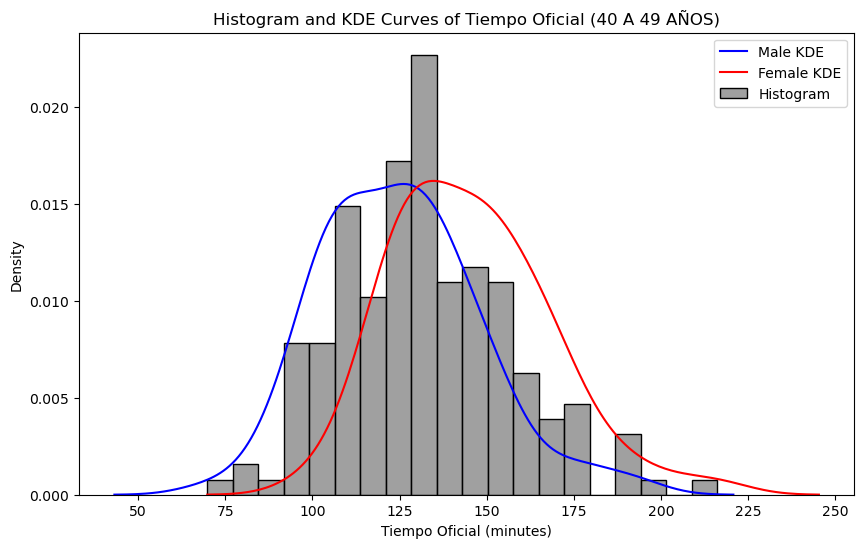

In [36]:
import seaborn as sns

import matplotlib.pyplot as plt

# Filter the data for the "40 A 49 AÑOS" category
filtered_df = df[df['Categoria'] == '40 A 49 AñOS']

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the histogram
sns.histplot(filtered_df, x='Tiempo Oficial', bins=20, color='gray', kde=False, label='Histogram', stat='density')

# Add KDE curves for each gender
sns.kdeplot(data=filtered_df[filtered_df['Genero'] == 'Masculino'], x='Tiempo Oficial', label='Male KDE', color='blue')
sns.kdeplot(data=filtered_df[filtered_df['Genero'] == 'Femenino'], x='Tiempo Oficial', label='Female KDE', color='red')

# Add labels and legend
plt.title('Histogram and KDE Curves of Tiempo Oficial (40 A 49 AÑOS)')
plt.xlabel('Tiempo Oficial (minutes)')
plt.ylabel('Density')
plt.legend()

# Show the plot
plt.show()

Genero           Femenino   Masculino  Difference
Categoria                                        
60 AñOS Y MAS  159.916667  124.716667   35.200000
40 A 49 AñOS   145.196766  124.693519   20.503248
50 A 59 AñOS   144.945726  124.541000   20.404726
18 A 39 AñOS   136.215044  121.205169   15.009875


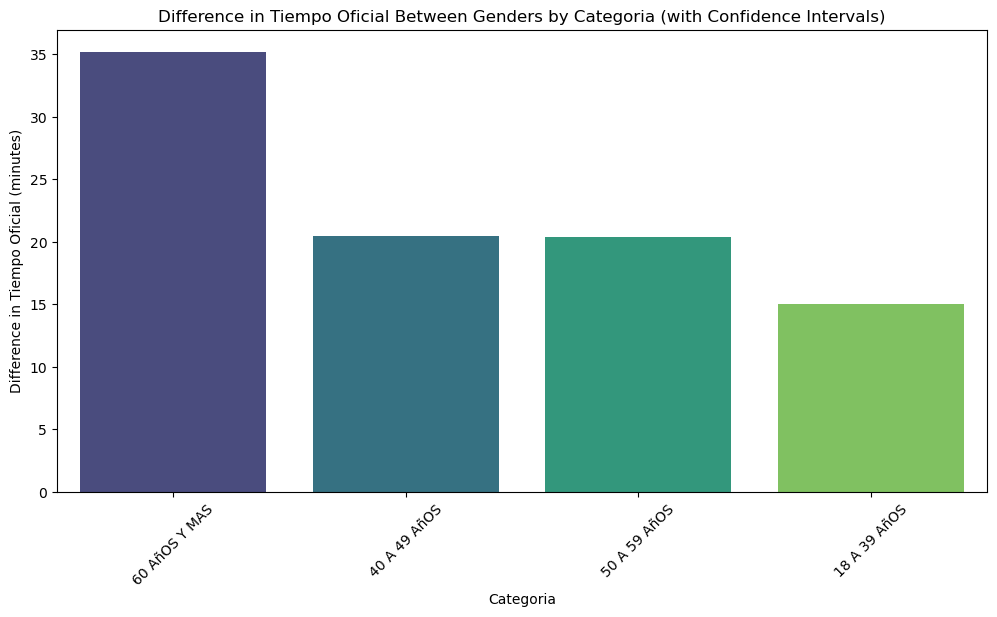

In [41]:
# Group by 'Categoria' and 'Genero' and calculate the mean 'Tiempo Oficial'
mean_times = df.groupby(['Categoria', 'Genero'])['Tiempo Oficial'].mean().unstack()

# Calculate the absolute difference between genders for each 'Categoria'
mean_times['Difference'] = abs(mean_times['Masculino'] - mean_times['Femenino'])

# Sort by the difference to find the 'Categoria' with the biggest difference
sorted_diff = mean_times.sort_values(by='Difference', ascending=False)

# Display the result


print(sorted_diff)
# Plot the differences with confidence intervals
plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_diff.index, y=sorted_diff['Difference'], palette='viridis', errorbar='sd')
plt.title('Difference in Tiempo Oficial Between Genders by Categoria (with Confidence Intervals)')
plt.xlabel('Categoria')
plt.ylabel('Difference in Tiempo Oficial (minutes)')
plt.xticks(rotation=45)
plt.show()

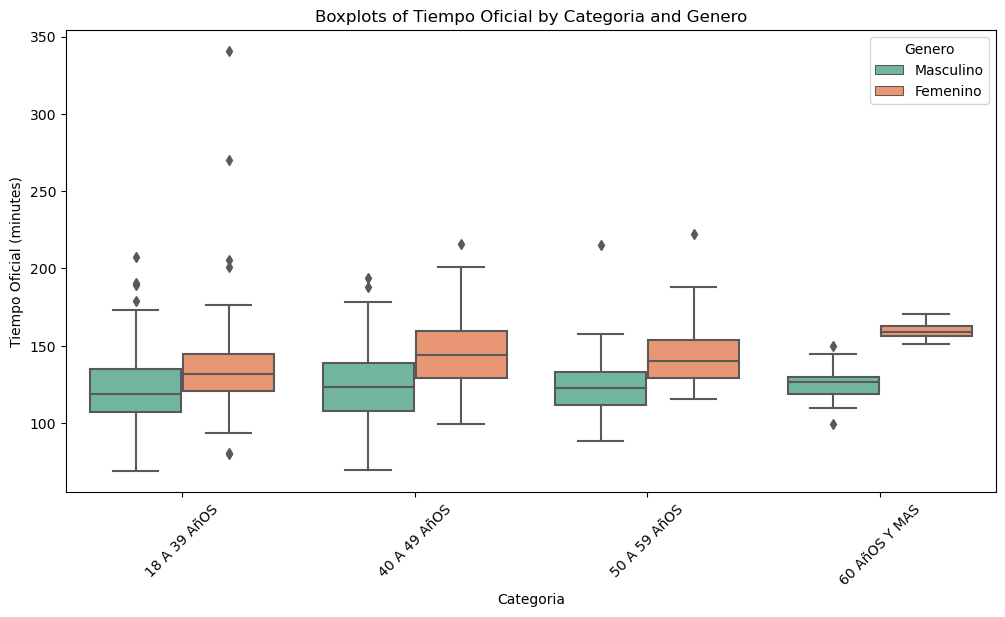

In [42]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Categoria', y='Tiempo Oficial', hue='Genero', palette='Set2')
plt.title('Boxplots of Tiempo Oficial by Categoria and Genero')
plt.xlabel('Categoria')
plt.ylabel('Tiempo Oficial (minutes)')
plt.xticks(rotation=45)
plt.legend(title='Genero')
plt.show()

# How different were the winners to the rest of their group

In [43]:
from scipy.stats import norm

# Group the data by 'Categoria' and 'Genero'
grouped = df.groupby(['Categoria', 'Genero'])

# Create a dictionary to store the results
results = {}

# Iterate through each group
for (categoria, genero), group in grouped:
    # Estimate the parameters of the normal distribution
    mean = group['Tiempo Oficial'].mean()
    std = group['Tiempo Oficial'].std()
    
    # Find the lowest 'Tiempo Oficial' in the group
    lowest_time = group['Tiempo Oficial'].min()
    
    # Calculate the cumulative probability up to the lowest time
    cumulative_prob = norm.cdf(lowest_time, loc=mean, scale=std)
    
    # Store the results
    results[(categoria, genero)] = {
        'Mean': mean,
        'StdDev': std,
        'Lowest Tiempo Oficial': lowest_time,
        'Cumulative Probability': cumulative_prob
    }

# Display the results
for key, value in results.items():
    print(f"Categoria: {key[0]}, Genero: {key[1]}")
    print(f"  Mean: {value['Mean']:.2f}, StdDev: {value['StdDev']:.2f}")
    print(f"  Lowest Tiempo Oficial: {value['Lowest Tiempo Oficial']:.2f}")
    print(f"  Cumulative Probability: {value['Cumulative Probability']:.4f}")
    print()

Categoria: 18 A 39 AñOS, Genero: Femenino
  Mean: 136.22, StdDev: 30.54
  Lowest Tiempo Oficial: 80.12
  Cumulative Probability: 0.0331

Categoria: 18 A 39 AñOS, Genero: Masculino
  Mean: 121.21, StdDev: 24.29
  Lowest Tiempo Oficial: 69.00
  Cumulative Probability: 0.0158

Categoria: 40 A 49 AñOS, Genero: Femenino
  Mean: 145.20, StdDev: 22.58
  Lowest Tiempo Oficial: 99.05
  Cumulative Probability: 0.0205

Categoria: 40 A 49 AñOS, Genero: Masculino
  Mean: 124.69, StdDev: 22.71
  Lowest Tiempo Oficial: 69.88
  Cumulative Probability: 0.0079

Categoria: 50 A 59 AñOS, Genero: Femenino
  Mean: 144.95, StdDev: 21.82
  Lowest Tiempo Oficial: 115.45
  Cumulative Probability: 0.0883

Categoria: 50 A 59 AñOS, Genero: Masculino
  Mean: 124.54, StdDev: 21.30
  Lowest Tiempo Oficial: 88.22
  Cumulative Probability: 0.0440

Categoria: 60 AñOS Y MAS, Genero: Femenino
  Mean: 159.92, StdDev: 8.17
  Lowest Tiempo Oficial: 150.82
  Cumulative Probability: 0.1328

Categoria: 60 AñOS Y MAS, Genero: Ma

In [ ]:
df[(df['Categoria'] == "18 A 39 AñOS") & (df['Genero'] == "Masculino")]

,Genero,BIB,Tiempo Chip,Paso Medio,Categoria,Tiempo Oficial,Name


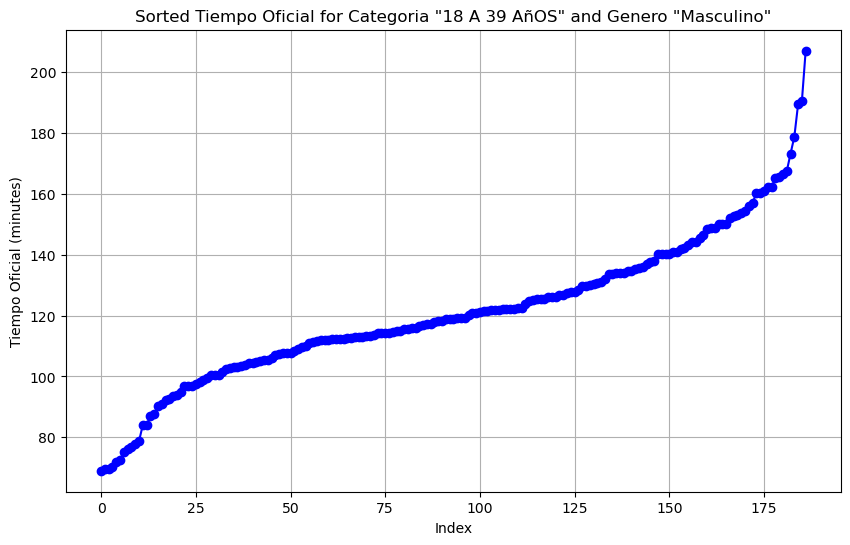

In [51]:
# Filter the data for the specified category and gender
filtered_data = df[(df['Categoria'] == "18 A 39 AñOS") & (df['Genero'] == "Masculino")]

# Sort the 'Tiempo Oficial' values
sorted_times = filtered_data['Tiempo Oficial'].sort_values()

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(sorted_times.values, marker='o', linestyle='-', color='blue')
plt.title('Sorted Tiempo Oficial for Categoria "18 A 39 AñOS" and Genero "Masculino"')
plt.xlabel('Index')
plt.ylabel('Tiempo Oficial (minutes)')
plt.grid()
plt.show()

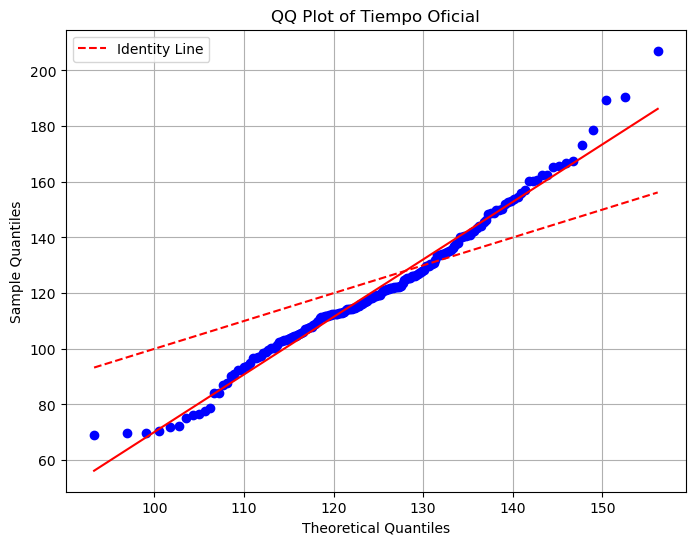

In [53]:
from scipy import stats

# Generate the QQ plot
plt.figure(figsize=(8, 6))
res = stats.probplot(filtered_data['Tiempo Oficial'], dist="norm", sparams=(value['Mean'], std), plot=plt)

# Add the identity line
plt.plot([res[0][0][0], res[0][0][-1]], [res[0][0][0], res[0][0][-1]], color='red', linestyle='--', label='Identity Line')

# Add labels, title, and legend
plt.title('QQ Plot of Tiempo Oficial')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.legend()

# Show the plot
plt.grid()
plt.show()

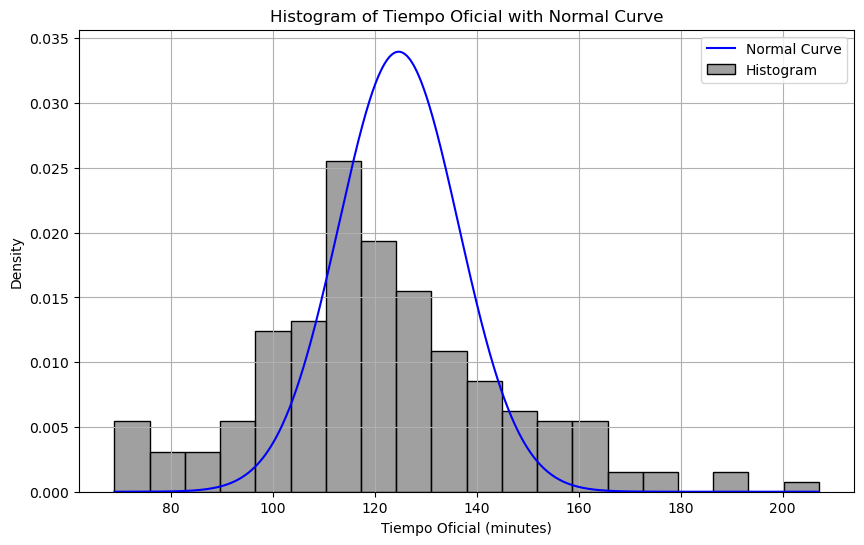

In [54]:
import numpy as np

# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(filtered_data['Tiempo Oficial'], bins=20, kde=False, color='gray', stat='density', label='Histogram')

# Generate the x values for the normal curve
x = np.linspace(filtered_data['Tiempo Oficial'].min(), filtered_data['Tiempo Oficial'].max(), 1000)

# Calculate the y values for the normal curve
y = norm.pdf(x, loc=value['Mean'], scale=std)

# Plot the normal curve
plt.plot(x, y, color='blue', label='Normal Curve')

# Add labels, title, and legend
plt.title('Histogram of Tiempo Oficial with Normal Curve')
plt.xlabel('Tiempo Oficial (minutes)')
plt.ylabel('Density')
plt.legend()

# Show the plot
plt.grid()
plt.show()

## How elite the elite were

Shape: 41.947663310504446, Location: -35.30903756685567, Scale: 3.7311782367701385


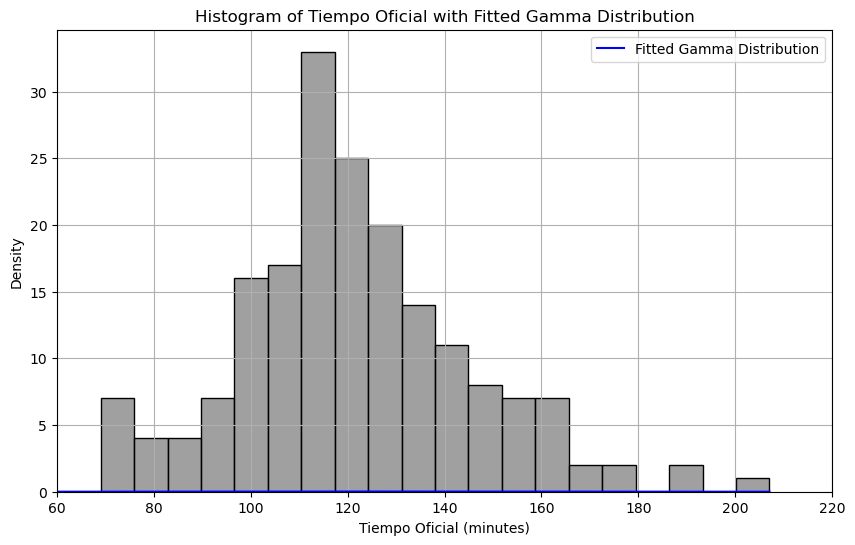

In [59]:
from scipy.stats import gamma

# Extract the 'Tiempo Oficial' data from the filtered DataFrame
data = filtered_data['Tiempo Oficial']

# Fit a gamma distribution to the data
shape, loc, scale = gamma.fit(data)

# Print the parameters of the fitted gamma distribution
print(f"Shape: {shape}, Location: {loc}, Scale: {scale}")

# Plot the histogram of the data and the fitted gamma distribution
plt.figure(figsize=(10, 6))
sns.histplot(data, bins=20, kde=False, color='gray')#, stat='density', label='Histogram')

# Generate x values for the gamma distribution
x = np.linspace(50, data.max(), 1000)

# Calculate the y values for the gamma distribution
y_gamma = gamma.pdf(x, shape, loc=loc, scale=scale)

# Plot the gamma distribution
plt.plot(x, y_gamma, color='blue', label='Fitted Gamma Distribution')

# Add labels, title, and legend
plt.title('Histogram of Tiempo Oficial with Fitted Gamma Distribution')
plt.xlabel('Tiempo Oficial (minutes)')
plt.ylabel('Density')
plt.legend()
plt.xlim(60,220)

# Show the plot
plt.grid()
plt.show()

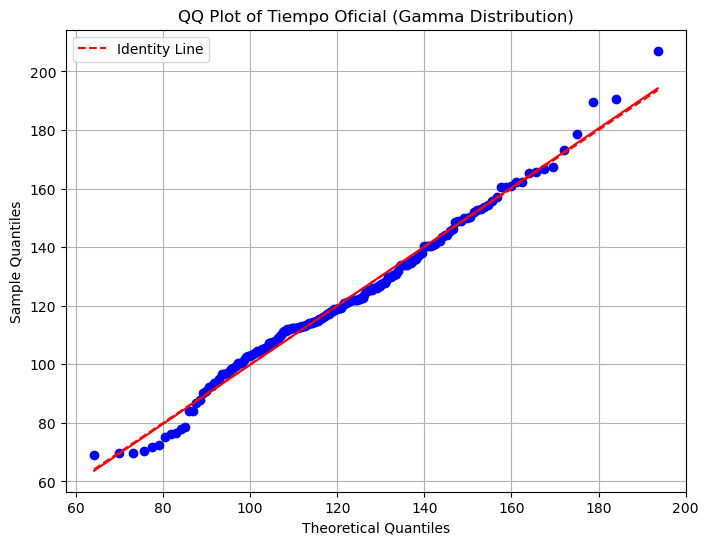

In [56]:
# Generate the QQ plot for the Gamma distribution
plt.figure(figsize=(8, 6))
res = stats.probplot(data, dist="gamma", sparams=(shape, loc, scale), plot=plt)

# Add the identity line
plt.plot([res[0][0][0], res[0][0][-1]], [res[0][0][0], res[0][0][-1]], color='red', linestyle='--', label='Identity Line')

# Add labels, title, and legend
plt.title('QQ Plot of Tiempo Oficial (Gamma Distribution)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.legend()

# Show the plot
plt.grid()
plt.show()